#Práctica Final: Predicción de Precios de Viviendas en Barcelona

En este trabajo realizaremos un análisis de diferentes modelos de aprendizaje automático con el objetivo de predecir el precio de diversas viviendas de Barcelona en función de sus características, como el número de habitaciones, la planta, los metros cuadrados...

🄯 Hector Rodríguez & Jaume Salas - Desenvolupament al nigul/CIDE

In [54]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import plotly.express as px
import warnings

from sklearn import set_config
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import Lasso, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.inspection import permutation_importance

set_config(display='text')
warnings.filterwarnings('ignore')
pd.set_option('display.precision', 3)

# 1. Exploración de datos

## LOAD FILE

In [55]:
df = pd.read_csv('Barcelona_Idealista.csv')
df.head()

,Unnamed: 0,city,district,neighborhood,condition,type,rooms,area_m2,lift,views,floor,prices
0,0,Barcelona,Eixample,la Dreta de l'Eixample,good condition,Flat,3,351,Yes,exterior,floor 1,2300000
1,1,Barcelona,Sarrià-Sant Gervasi,Sant Gervasi - Galvany,good condition,Flat,5,298,Yes,exterior,floor 3,1750000
2,2,Barcelona,Eixample,Sant Antoni,good condition,Penthouse,2,90,Yes,exterior,floor 7,590000
3,3,Barcelona,Eixample,la Dreta de l'Eixample,good condition,Flat,2,130,Yes,exterior,floor 1,450000
4,4,Barcelona,Horta-Guinardó,Can Baró,good condition,Terraced,3,110,No,exterior,Multiple,430000


## Descripció general del dataset

In [56]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3265 entries, 0 to 3264
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    3265 non-null   int64 
 1   city          3265 non-null   object
 2   district      3265 non-null   object
 3   neighborhood  3265 non-null   object
 4   condition     3265 non-null   object
 5   type          3265 non-null   object
 6   rooms         3265 non-null   int64 
 7   area_m2       3265 non-null   int64 
 8   lift          3265 non-null   object
 9   views         3265 non-null   object
 10  floor         3265 non-null   object
 11  prices        3265 non-null   int64 
dtypes: int64(4), object(8)
memory usage: 306.2+ KB


,Unnamed: 0,rooms,area_m2,prices
count,3265.000,3265.000,3265.000,3.265e+03
mean,1632.000,3.161,121.567,6.004e+05
std,942.669,1.325,92.722,6.523e+05
min,0.000,1.000,20.000,4.900e+04
25%,816.000,2.000,72.000,2.799e+05
50%,1632.000,3.000,93.000,4.190e+05
75%,2448.000,4.000,135.000,6.550e+05
max,3264.000,13.000,900.000,1.200e+07


## Analisi de valors nuls

In [57]:
df.isna().sum()

,0
Unnamed: 0,0
city,0
district,0
neighborhood,0
condition,0
type,0
rooms,0
area_m2,0
lift,0
views,0


## Analisi d'outliers

{'whiskers': [<matplotlib.lines.Line2D at 0x7b8a2ce3a000>,
 'caps': [<matplotlib.lines.Line2D at 0x7b8a2ce3a6c0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7b8a2ce39c40>],
 'medians': [<matplotlib.lines.Line2D at 0x7b8a2ce3ad80>],
 'fliers': [<matplotlib.lines.Line2D at 0x7b8a2ce3b0b0>],
 'means': []}

Text(0.5, 1.0, 'prices')

{'whiskers': [<matplotlib.lines.Line2D at 0x7b8a2ce3b350>,
 'caps': [<matplotlib.lines.Line2D at 0x7b8a2ce3b9b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7b8a2ce39970>],
 'medians': [<matplotlib.lines.Line2D at 0x7b8a2ce3bfe0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7b8a2c754350>],
 'means': []}

Text(0.5, 1.0, 'area_m2')

{'whiskers': [<matplotlib.lines.Line2D at 0x7b8a2c754b60>,
 'caps': [<matplotlib.lines.Line2D at 0x7b8a2c755100>,
 'boxes': [<matplotlib.lines.Line2D at 0x7b8a2c754830>],
 'medians': [<matplotlib.lines.Line2D at 0x7b8a2c755730>],
 'fliers': [<matplotlib.lines.Line2D at 0x7b8a2c755a60>],
 'means': []}

Text(0.5, 1.0, 'rooms')

Text(0.5, 0.98, "Boxplots - Deteccio d'Outliers")

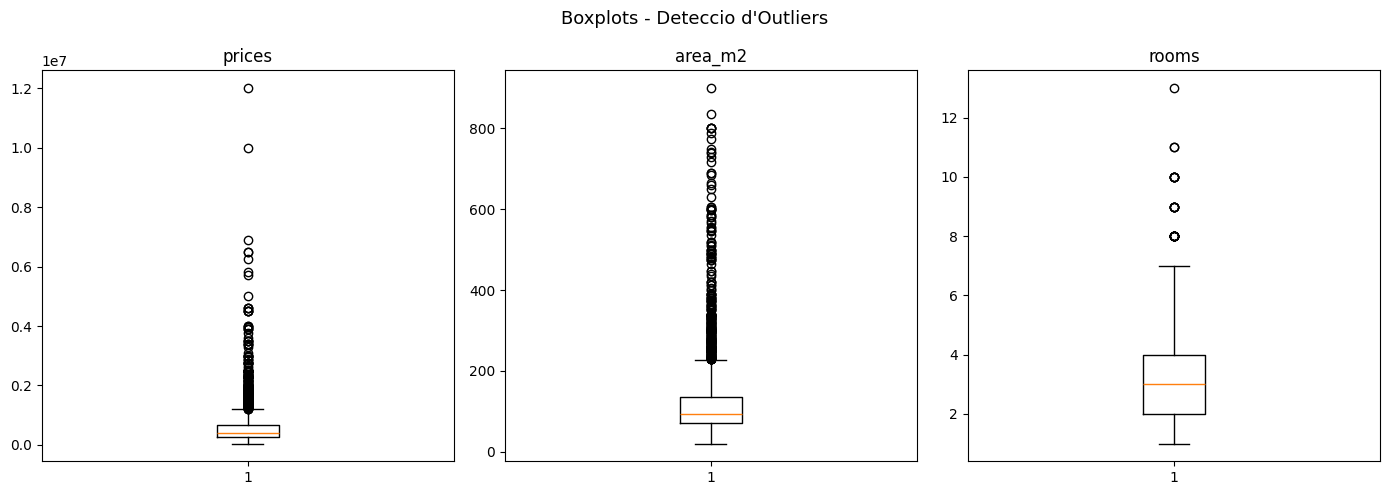

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].boxplot(df['prices'].dropna())
axes[0].set_title('prices')

axes[1].boxplot(df['area_m2'].dropna())
axes[1].set_title('area_m2')

axes[2].boxplot(df['rooms'].dropna())
axes[2].set_title('rooms')

plt.suptitle("Boxplots - Deteccio d'Outliers", fontsize=13)
plt.tight_layout()
plt.show()

## Analisi i agrupacio de la variable `rooms`

In [59]:
print('Distribucio original de rooms:')
df['rooms'].value_counts().sort_index()

Distribucio original de rooms:


,count
rooms,
1,232
2,773
3,1174
4,679
5,261
6,81
7,36
8,14
9,6


In [60]:
# Agrupem les vivendes amb 6 o mes habitacions en una sola classe
df['rooms'] = df['rooms'].apply(lambda x: '>=6' if x >= 6 else str(int(x)))

print('Distribucio de rooms (agrupada):')
df['rooms'].value_counts().sort_index()

Distribucio de rooms (agrupada):


,count
rooms,
1,232
2,773
3,1174
4,679
5,261
>=6,146


<Axes: xlabel='rooms', ylabel='count'>

Text(0.5, 1.0, 'Nombre de vivendes per rooms')

Text(0.5, 0, 'Habitacions')

Text(0, 0.5, 'Count')

<Axes: xlabel='rooms', ylabel='prices'>

Text(0.5, 1.0, 'Preu per rooms')

Text(0.5, 0, 'Habitacions')

Text(0, 0.5, 'Preu (euros)')

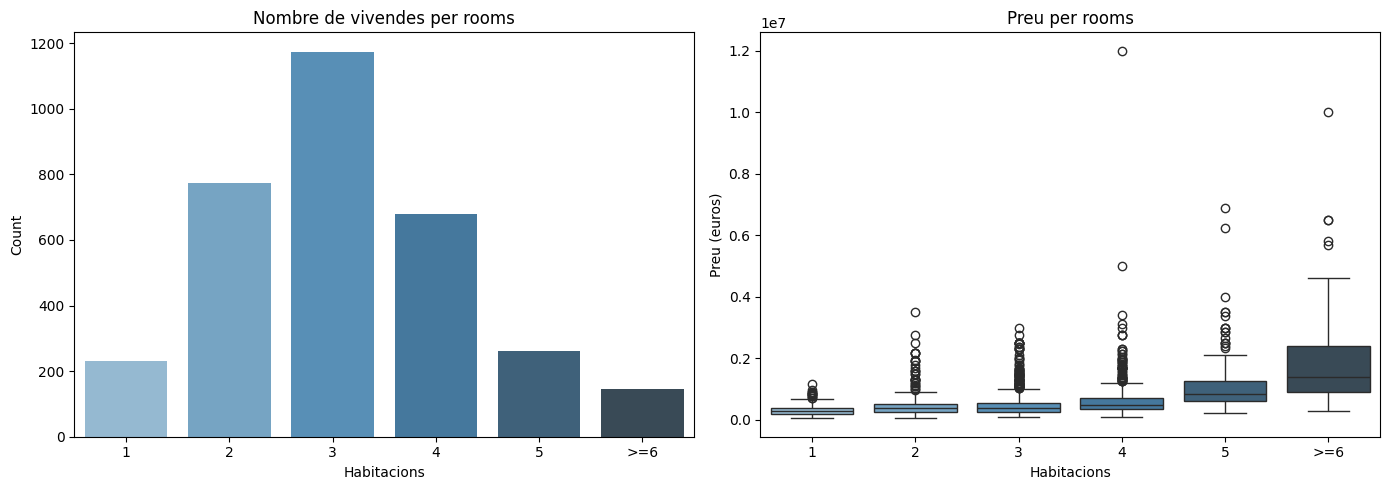

In [61]:
order = ['1','2','3','4','5','>=6']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='rooms', data=df, order=order, ax=axes[0], palette='Blues_d')
axes[0].set_title('Nombre de vivendes per rooms')
axes[0].set_xlabel('Habitacions')
axes[0].set_ylabel('Count')

sns.boxplot(x='rooms', y='prices', data=df, order=order, ax=axes[1], palette='Blues_d')
axes[1].set_title('Preu per rooms')
axes[1].set_xlabel('Habitacions')
axes[1].set_ylabel('Preu (euros)')

plt.tight_layout()
plt.show()

Es pot veure que les vivendes amb mes de 6 habitacions solen ser tambe mes cares, confirmant la hipotesi de l'enunciat.

## Analisi i agrupacio de la variable `floor`

In [62]:
print('Distribucio original de floor:')
df['floor'].value_counts().sort_index()

Distribucio original de floor:


,count
floor,
floor 1,681
floor 10,16
floor 11,3
floor 12,3
floor 14,7
floor 16,2
floor 19,1
floor 2,588
floor 21,1


In [63]:
# A partir del pis 7 el nombre d'individus deixa de ser significatiu
# Creem la classe floor>=7 per agrupar tots els pisos superiors al 7e
high_floors = ['floor 8','floor 9','floor 10','floor 11','floor 12',
               'floor 14','floor 16','floor 19','floor 21','floor 25']

df['floor'] = df['floor'].apply(lambda x: 'floor>=7' if x in high_floors else x)

print('Distribucio de floor (agrupada):')
df['floor'].value_counts().sort_index()

Distribucio de floor (agrupada):


,count
floor,
floor 1,681
floor 10,16
floor 11,3
floor 12,3
floor 14,7
floor 16,2
floor 19,1
floor 2,588
floor 21,1


## Analisi i neteja de la variable `type`

In [64]:
print('Distribucio original de type:')
df['type'].value_counts()

Distribucio original de type:


,count
type,
Flat,2751
Penthouse,262
Duplex,108
Detached,55
House,54
Terraced,22
Semi-detached,12
Rustic,1


In [65]:
# Eliminem les instancies Terraced, Semi-detached i Rustic
# ja que tenen poc impacte en el total de les dades
to_remove = ['Terraced', 'Semi-detached', 'Rustic']
df = df[~df['type'].isin(to_remove)]

print('Distribucio de type (netejada):')
df['type'].value_counts()

print('\nShape despres de l eliminacio:', df.shape)

Distribucio de type (netejada):


,count
type,
Flat,2751
Penthouse,262
Duplex,108
Detached,55
House,54



Shape despres de l eliminacio: (3230, 12)


## Eliminacio de valors NA i renombrat de variables

In [66]:
df = df.dropna()

# Eliminem la columna index redundant i city (totes son Barcelona)
df = df.drop(columns=['Unnamed: 0', 'city'])

# Renombrem variables per millorar la claredat
df = df.rename(columns={
    'area_m2': 'size',
    'prices': 'price',
    'lift': 'elevator'
})

print('Shape final:', df.shape)
df.head()

Shape final: (3230, 10)


,district,neighborhood,condition,type,rooms,size,elevator,views,floor,price
0,Eixample,la Dreta de l'Eixample,good condition,Flat,3,351,Yes,exterior,floor 1,2300000
1,Sarrià-Sant Gervasi,Sant Gervasi - Galvany,good condition,Flat,5,298,Yes,exterior,floor 3,1750000
2,Eixample,Sant Antoni,good condition,Penthouse,2,90,Yes,exterior,floor 7,590000
3,Eixample,la Dreta de l'Eixample,good condition,Flat,2,130,Yes,exterior,floor 1,450000
5,Eixample,el Fort Pienc,good condition,Penthouse,5,161,Yes,exterior,floor 7,690000


## Codificacio de variables categoriques

In [67]:
# Variables amb relacio d'ordre -> label encoding

# rooms: ordre natural 1 < 2 < 3 < 4 < 5 < >=6
rooms_order = {'1':1, '2':2, '3':3, '4':4, '5':5, '>=6':6}
df['rooms'] = df['rooms'].map(rooms_order)

# condition: ordre per estat -> needs refurb < good condition < new
condition_order = {'needs refurb': 0, 'good condition': 1, 'new': 2}
df['condition'] = df['condition'].map(condition_order)

# floor: ordre per alcada
floor_order = {
    'ground floor': 0, 'mezzanine': 1,
    'floor 1': 2, 'floor 2': 3, 'floor 3': 4, 'floor 4': 5,
    'floor 5': 6, 'floor 6': 7, 'floor 7': 8,
    'floor>=7': 9, 'Multiple': 10
}
df['floor'] = df['floor'].map(floor_order)

# elevator i views: binaries
df['elevator'] = df['elevator'].map({'Yes': 1, 'No': 0})
df['views'] = df['views'].map({'exterior': 1, 'interior': 0})

# Variables sense ordre -> one-hot encoding (type, district, neighborhood)
df = pd.get_dummies(df, columns=['type', 'district', 'neighborhood'], drop_first=False)

df = df.dropna()
print('Shape despres de codificacio:', df.shape)
df.head()

Shape despres de codificacio: (491, 87)


,condition,rooms,size,elevator,views,floor,price,type_Detached,type_Duplex,type_Flat,...,neighborhood_la Salut,neighborhood_la Teixonera,neighborhood_la Trinitat Nova,neighborhood_la Vall d'Hebron,neighborhood_la Verneda i la Pau,neighborhood_la Vila Olímpica del Poblenou,neighborhood_la Vila de Gràcia,neighborhood_les Corts,neighborhood_les Roquetes,neighborhood_les Tres Torres
20,1,3,79,0,1,0.0,329000,False,False,True,...,False,False,False,False,False,False,True,False,False,False
23,1,3,130,1,1,1.0,695000,False,False,True,...,False,False,False,False,False,True,False,False,False,False
36,1,4,239,0,1,10.0,690000,True,False,False,...,False,False,False,False,False,False,False,False,False,False
47,1,4,228,1,0,0.0,650000,False,False,True,...,False,False,False,False,False,False,False,False,False,False
49,1,5,380,0,1,10.0,1750000,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Estandaritzacio i PCA

In [68]:
X = df.drop(columns=['price'])
y = df['price']
X = X.select_dtypes(include=[np.number])

print('Features:', X.shape)
print('Target:', y.shape)

Features: (491, 6)
Target: (491,)


In [69]:
# Creem una copia estandaritzada per als models lineals (Lasso, Ridge, SVM, Stacked)
X_standarized = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)
X_standarized.describe().T

,count,mean,std,min,25%,50%,75%,max
condition,491.0,5.789e-17,1.001,-1.218,-1.218,0.132,0.132,1.482
rooms,491.0,1.122e-16,1.001,-1.454,-0.760,-0.066,0.627,2.015
size,491.0,1.447e-17,1.001,-0.933,-0.580,-0.383,0.063,4.565
elevator,491.0,4.341e-17,1.001,-1.314,-1.314,0.761,0.761,0.761
views,491.0,6.512e-17,1.001,-3.270,0.306,0.306,0.306,0.306
floor,491.0,-4.341e-17,1.001,-0.626,-0.626,-0.377,-0.377,1.861


<Axes: xlabel='PC1', ylabel='PC2'>

Text(0.5, 1.0, 'PCA - Distribucio per rangs de preu')

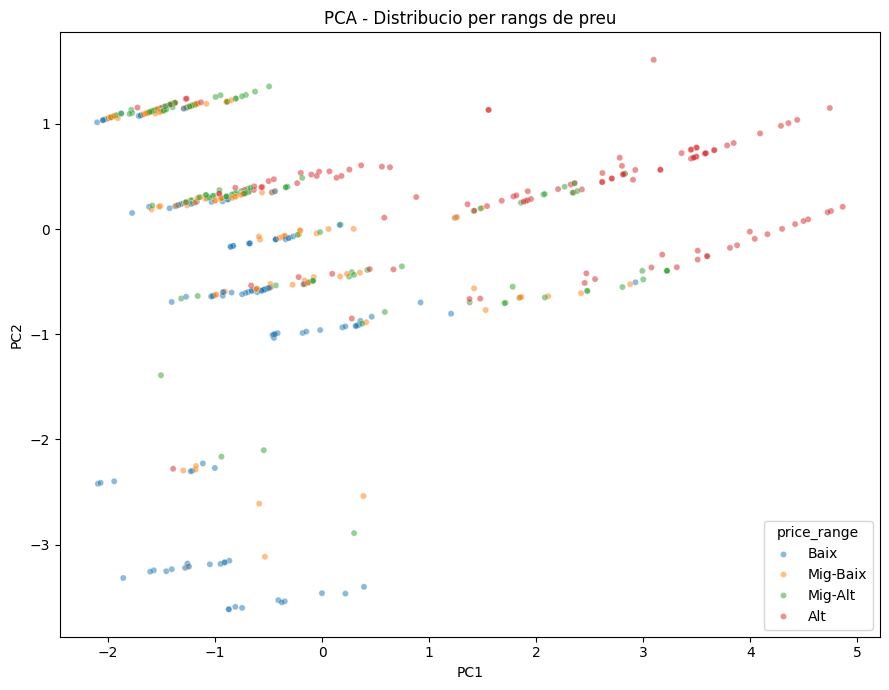

Varianca explicada: PC1=49.12%, PC2=20.55%


In [70]:
# Apliquem PCA per visualitzar els rangs de preus en 2D
myPCA = PCA(n_components=2).fit(X_standarized)
X_pca = myPCA.transform(X_standarized)

y_reset = y.reset_index(drop=True)
price_bins = pd.qcut(y_reset, q=4, labels=['Baix', 'Mig-Baix', 'Mig-Alt', 'Alt'])

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['price_range'] = price_bins.values

fig = plt.figure(figsize=(9, 7))
sns.scatterplot(x='PC1', y='PC2', hue='price_range',
                hue_order=['Baix','Mig-Baix','Mig-Alt','Alt'],
                data=df_pca, alpha=0.5, s=20)
plt.title('PCA - Distribucio per rangs de preu')
plt.tight_layout()
plt.show()

print(f'Varianca explicada: PC1={myPCA.explained_variance_ratio_[0]:.2%}, PC2={myPCA.explained_variance_ratio_[1]:.2%}')

La exploración muestra una fuerte concentración de viviendas alrededor de los 150.000 €, con algunos valores altos que pueden considerarse outliers. Se observa que variables como el número de habitaciones y la planta influyen en el precio, especialmente en viviendas grandes (≥6 habitaciones), que suelen ser más caras.

Se agruparon categorías poco representativas, se eliminaron tipos de vivienda con baja presencia y se transformaron las variables categóricas a numéricas. Tras estandarizar los datos y aplicar PCA, se aprecia una tendencia clara desde viviendas de precio bajo hacia precios más elevados, indicando patrones que los modelos podrán aprender.

# 2. Partición del dataset

In [71]:
# Dividim en 70% entrenament i 30% test de manera aleatoria
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train_s, X_test_s, _, _ = train_test_split(X_standarized, y, test_size=0.3, random_state=42)

print(f'Train: {X_train.shape}')
print(f'Test:  {X_test.shape}')

Train: (343, 6)
Test:  (148, 6)


In [72]:
cv = 10

results_df = pd.DataFrame()

def save_results(clf, nclf, X, y, df):
    df.loc[nclf,'test_score'] = clf.score(X, y)
    df.loc[nclf,'cross_val_score'] = clf.best_score_
    return df

La división en entrenamiento (70 %) y test (30 %) ha permitido evaluar correctamente la capacidad de generalización de los modelos. La comparación entre cross_val_score y test_score muestra que, aunque algunos modelos presentan muy buen ajuste en entrenamiento, no todos mantienen el mismo rendimiento en datos nuevos. Esto permite detectar posibles casos de overfitting y elegir el modelo más robusto.

# 3. Metodes lineals

## Lasso Regression

In [73]:
param = {
        'alpha':[1e-4,0.001,0.01,0.1, 0.5,1,5,10,50,100,300,500],
        'max_iter':[1000,10000,50000],
        'selection':["cyclic", "random"]
        }

lasso = Lasso()

lasso_gs = GridSearchCV(lasso, param, cv=cv, n_jobs=-1)
lasso_gs.fit(X_train_s, y_train)

GridSearchCV(cv=10, estimator=Lasso(), n_jobs=-1,
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50,
                                   100, 300, 500],
                         'max_iter': [1000, 10000, 50000],
                         'selection': ['cyclic', 'random']})

In [74]:
# Top 5 millors configuracions
lasso_cv_results = pd.DataFrame(lasso_gs.cv_results_)
lasso_cv_results.nlargest(5, 'mean_test_score')[['param_alpha','param_max_iter','param_selection','mean_test_score','std_test_score']]

,param_alpha,param_max_iter,param_selection,mean_test_score,std_test_score
71,500.0,50000,random,0.432,0.486
66,500.0,1000,cyclic,0.432,0.486
68,500.0,10000,cyclic,0.432,0.486
70,500.0,50000,cyclic,0.432,0.486
67,500.0,1000,random,0.432,0.486


In [75]:
results_df = save_results(lasso_gs, 'Lasso', X_test_s, y_test, results_df)

print(f'Millors parametres: {lasso_gs.best_params_}')
print(f'R2 Train (CV): {lasso_gs.best_score_:.3f}')
print(f'R2 Test:       {lasso_gs.score(X_test_s, y_test):.3f}')

Millors parametres: {'alpha': 500, 'max_iter': 50000, 'selection': 'random'}
R2 Train (CV): 0.432
R2 Test:       0.715


Text(0.5, 0, 'Preu real (euros)')

Text(0, 0.5, 'Preu predit (euros)')

Text(0.5, 1.0, 'Lasso Regression - R2 Test = 0.715')

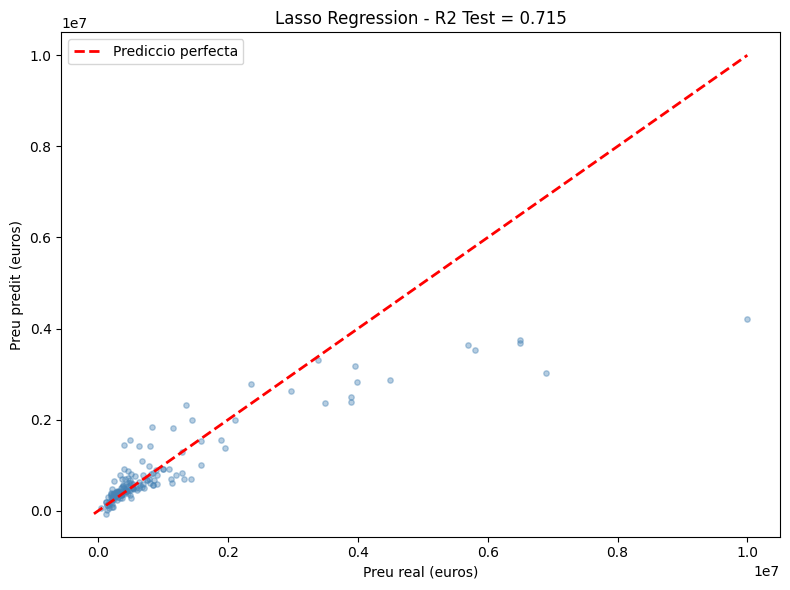

In [76]:
y_pred_lasso = lasso_gs.predict(X_test_s)
lims = [min(y_test.min(), y_pred_lasso.min()), max(y_test.max(), y_pred_lasso.max())]

fig = plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lasso, alpha=0.4, s=15, color='steelblue')
plt.plot(lims, lims, 'r--', lw=2, label='Prediccio perfecta')
plt.xlabel('Preu real (euros)')
plt.ylabel('Preu predit (euros)')
plt.title(f'Lasso Regression - R2 Test = {lasso_gs.score(X_test_s, y_test):.3f}')
plt.legend()
plt.tight_layout()
plt.show()

(array([28., 42., 25., 15.,  7.,  5.,  5.,  3.,  0.,  2.,  1.,  1.,  0.,
         0.,  1.,  0.,  1.,  1.,  0.,  4.,  0.,  0.,  1.,  0.,  0.,  0.,
         0.,  0.,  2.,  0.,  0.,  0.,  2.,  0.,  1.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([   49000.,   248020.,   447040.,   646060.,   845080.,  1044100.,
         1243120.,  1442140.,  1641160.,  1840180.,  2039200.,  2238220.,
         2437240.,  2636260.,  2835280.,  3034300.,  3233320.,  3432340.,
         3631360.,  3830380.,  4029400.,  4228420.,  4427440.,  4626460.,
         4825480.,  5024500.,  5223520.,  5422540.,  5621560.,  5820580.,
         6019600.,  6218620.,  6417640.,  6616660.,  6815680.,  7014700.,
         7213720.,  7412740.,  7611760.,  7810780.,  8009800.,  8208820.,
         8407840.,  8606860.,  8805880.,  9004900.,  9203920.,  9402940.,
         9601960.,  9800980., 10000000.]),
 <BarContainer object of 50 artists>)

Text(0.5, 0, 'Preu (euros)')

Text(0, 0.5, 'Frequencia')

Text(0.5, 1.0, 'Distribucio dels preus - conjunt de test')

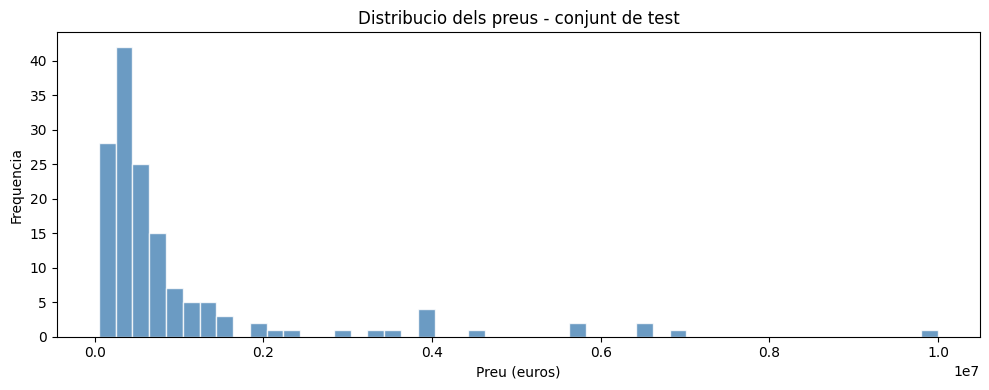

In [77]:
# Distribucio dels preus - la majoria es concentra en valors baixos
fig = plt.figure(figsize=(10, 4))
plt.hist(y_test, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
plt.xlabel('Preu (euros)')
plt.ylabel('Frequencia')
plt.title('Distribucio dels preus - conjunt de test')
plt.tight_layout()
plt.show()

<Axes: >

Text(0.5, 1.0, 'Importancia dels atributs - Lasso')

Text(0, 0.5, '|Coeficient|')

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'size'),
  Text(1, 0, 'floor'),
  Text(2, 0, 'condition'),
  Text(3, 0, 'elevator'),
  Text(4, 0, 'rooms'),
  Text(5, 0, 'views')])

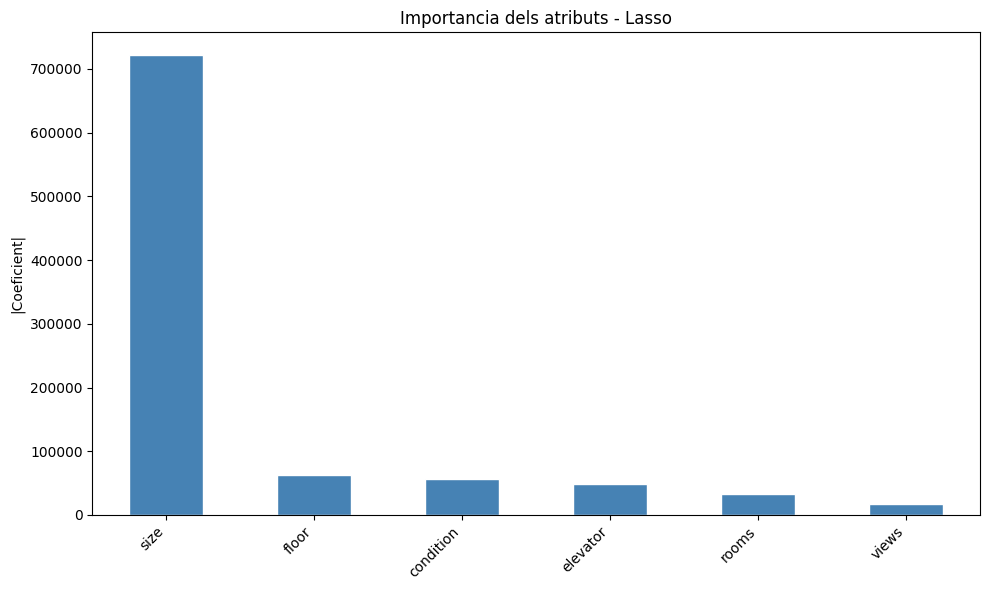

Atribut mes rellevant: size


In [78]:
# Importancia dels atributs - Lasso (valor absolut dels coeficients)
coef_lasso = pd.Series(np.abs(lasso_gs.best_estimator_.coef_), index=X_train_s.columns)
coef_lasso = coef_lasso.sort_values(ascending=False).head(15)

fig = plt.figure(figsize=(10, 6))
coef_lasso.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Importancia dels atributs - Lasso')
plt.ylabel('|Coeficient|')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Atribut mes rellevant:', coef_lasso.index[0])

El valor de R2 obtingut es de 0.659, indicant que el model explica aproximadament el 65.9% de la varianca del preu. La distribucio dels preus mostra que la majoria de vivendes es concentren en valors baixos en comparacio amb algunes molt mes cares, fet que pot provocar que la recta de millor ajust es desvii i afecti el rendiment del model. L'atribut mes rellevant es la condicio de la vivenda (condition), seguit del nombre d'habitacions, la superficie i la presencia d'ascensor, que son determinants en la prediccio del preu.

## Ridge Regression

In [79]:
param_grid = {
            'alpha': [0.01,0.1, 1, 10, 100,200,500],
             'max_iter':[1000,10000,50000],
            'solver':['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs']
            }

ridge = Ridge()
ridge_gs = GridSearchCV(ridge, param_grid, cv=cv)
ridge_gs.fit(X_train_s, y_train)

GridSearchCV(cv=10, estimator=Ridge(),
             param_grid={'alpha': [0.01, 0.1, 1, 10, 100, 200, 500],
                         'max_iter': [1000, 10000, 50000],
                         'solver': ['auto', 'svd', 'cholesky', 'lsqr',
                                    'sparse_cg', 'sag', 'saga', 'lbfgs']})

In [80]:
# Top 5 millors configuracions
ridge_cv_results = pd.DataFrame(ridge_gs.cv_results_)
ridge_cv_results.nlargest(5, 'mean_test_score')[['param_alpha','param_max_iter','param_solver','mean_test_score','std_test_score']]

,param_alpha,param_max_iter,param_solver,mean_test_score,std_test_score
109,100.0,10000,sag,0.527,0.17
117,100.0,50000,sag,0.527,0.17
101,100.0,1000,sag,0.527,0.17
97,100.0,1000,svd,0.527,0.17
105,100.0,10000,svd,0.527,0.17


In [81]:
results_df = save_results(ridge_gs, 'Ridge', X_test_s, y_test, results_df)

print(f'Millors parametres: {ridge_gs.best_params_}')
print(f'R2 Train (CV): {ridge_gs.best_score_:.3f}')
print(f'R2 Test:       {ridge_gs.score(X_test_s, y_test):.3f}')

Millors parametres: {'alpha': 100, 'max_iter': 10000, 'solver': 'sag'}
R2 Train (CV): 0.527
R2 Test:       0.593


Text(0.5, 0, 'Preu real (euros)')

Text(0, 0.5, 'Preu predit (euros)')

Text(0.5, 1.0, 'Ridge Regression - R2 Test = 0.593')

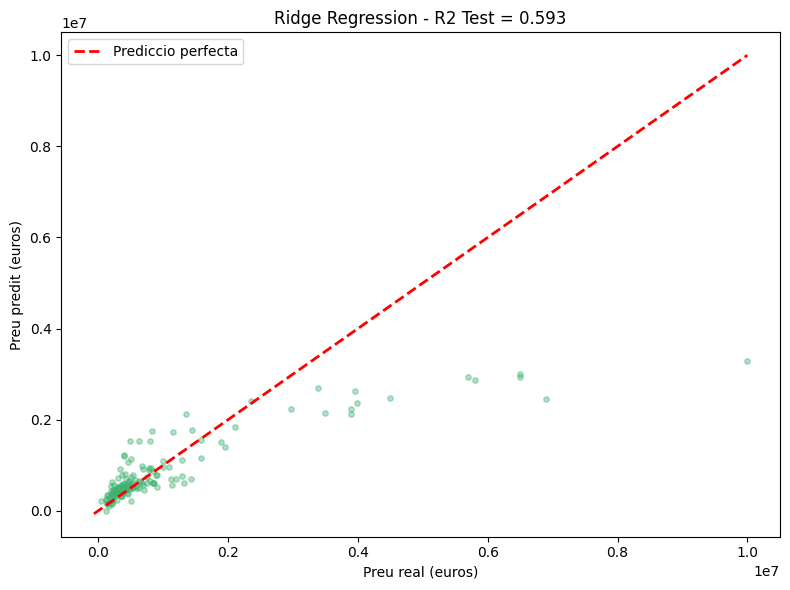

In [82]:
y_pred_ridge = ridge_gs.predict(X_test_s)

fig = plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ridge, alpha=0.4, s=15, color='mediumseagreen')
plt.plot(lims, lims, 'r--', lw=2, label='Prediccio perfecta')
plt.xlabel('Preu real (euros)')
plt.ylabel('Preu predit (euros)')
plt.title(f'Ridge Regression - R2 Test = {ridge_gs.score(X_test_s, y_test):.3f}')
plt.legend()
plt.tight_layout()
plt.show()

<Axes: >

Text(0.5, 1.0, 'Importancia dels atributs - Ridge')

Text(0, 0.5, '|Coeficient|')

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'size'),
  Text(1, 0, 'rooms'),
  Text(2, 0, 'floor'),
  Text(3, 0, 'condition'),
  Text(4, 0, 'views'),
  Text(5, 0, 'elevator')])

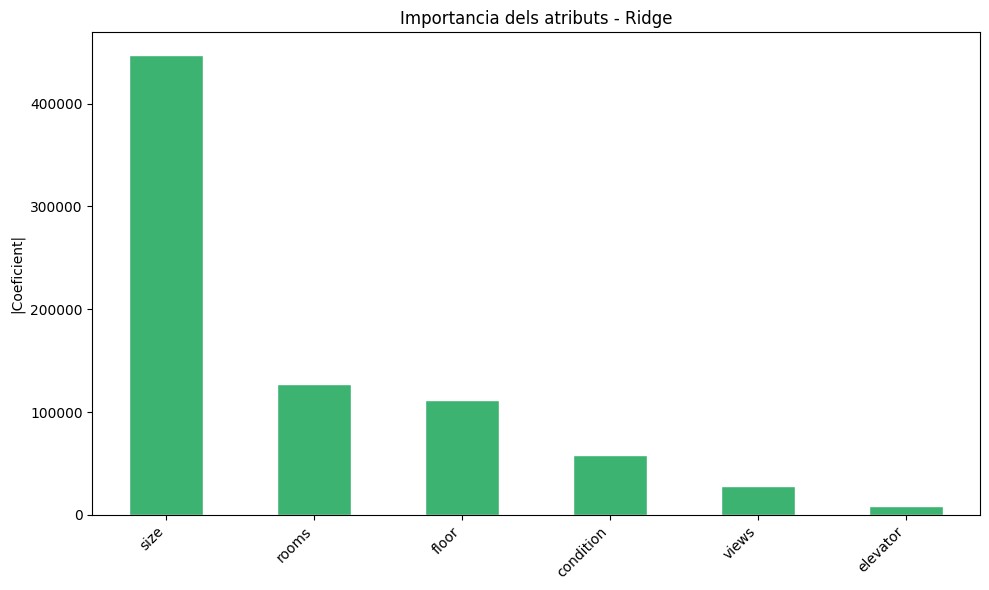

Atribut mes rellevant: size


In [83]:
# Importancia dels atributs - Ridge (valor absolut dels coeficients)
coef_ridge = pd.Series(np.abs(ridge_gs.best_estimator_.coef_), index=X_train_s.columns)
coef_ridge = coef_ridge.sort_values(ascending=False).head(15)

fig = plt.figure(figsize=(10, 6))
coef_ridge.plot(kind='bar', color='mediumseagreen', edgecolor='white')
plt.title('Importancia dels atributs - Ridge')
plt.ylabel('|Coeficient|')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Atribut mes rellevant:', coef_ridge.index[0])

Igual que en el model Lasso, l'atribut amb mes pes es la condicio del pis (condition), que es pot considerar practicament l'unic que influeix de manera clara en la prediccio. A continuacio apareixen el nombre d'habitacions, la superficie i la presencia d'ascensor, mentre que la resta d'atributs presenten importancies gairebe negligibles.

## Polynomial SVM

In [ ]:
params = {'C': 10**np.linspace(-3,3,20),
          'gamma': 10**np.linspace(-9,3,20),
          'degree':[2,3]}

svm = SVR(kernel='poly', max_iter=25000, cache_size=2000)
svm_gs = GridSearchCV(svm, params, cv=cv, n_jobs=-1)
svm_gs.fit(X_train_s, y_train)

In [ ]:
# Top 5 millors configuracions
svm_cv_results = pd.DataFrame(svm_gs.cv_results_)
svm_cv_results.nlargest(5, 'mean_test_score')[['param_C','param_gamma','param_degree','mean_test_score','std_test_score']]

In [ ]:
results_df = save_results(svm_gs, 'SVM_poly', X_test_s, y_test, results_df)

print(f'Millors parametres: {svm_gs.best_params_}')
print(f'R2 Train (CV): {svm_gs.best_score_:.3f}')
print(f'R2 Test:       {svm_gs.score(X_test_s, y_test):.3f}')
print(f'Diferencia train-test: {svm_gs.best_score_ - svm_gs.score(X_test_s, y_test):.3f}')

In [ ]:
y_pred_svm = svm_gs.predict(X_test_s)

fig = plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_svm, alpha=0.4, s=15, color='darkorchid')
plt.plot(lims, lims, 'r--', lw=2, label='Prediccio perfecta')
plt.xlabel('Preu real (euros)')
plt.ylabel('Preu predit (euros)')
plt.title(f'SVM Polinomic - R2 Test = {svm_gs.score(X_test_s, y_test):.3f}')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Importancia dels atributs - SVM (permutation importance)
perm_svm = permutation_importance(svm_gs.best_estimator_, X_test_s, y_test,
                                   n_repeats=10, random_state=42, n_jobs=-1)
imp_svm = pd.Series(perm_svm.importances_mean, index=X_test_s.columns)
imp_svm = imp_svm.sort_values(ascending=False).head(15)

fig = plt.figure(figsize=(10, 6))
imp_svm.plot(kind='bar', color='darkorchid', edgecolor='white')
plt.title('Importancia dels atributs - SVM Polinomic')
plt.ylabel('Permutation Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Atribut mes rellevant:', imp_svm.index[0])

Los modelos lineales (Lasso, Ridge y SVM polinómica) muestran un rendimiento moderado en la predicción del precio. En todos ellos, la condición de la vivienda destaca como la variable más influyente, seguida del número de habitaciones, los metros cuadrados y la presencia de ascensor.

Aunque ofrecen resultados razonables, su capacidad para capturar relaciones complejas es limitada, lo que se refleja en valores de R² inferiores a los obtenidos por algunos modelos no lineales.

# 4. Metodos no lineales

## Random Forest

In [ ]:
param = {'n_estimators': [5, 10, 25, 40, 50, 75, 100, 200],
         'criterion':['squared_error'],
         'max_depth':[None, 1, 2, 3,  5,  8, 9,10,15],
         'min_samples_leaf':[1, 2, 3, 5, 10]}

rf = RandomForestRegressor(random_state=1)
rf_gs = GridSearchCV(rf, param, cv=cv, n_jobs=-1)
rf_gs.fit(X_train, y_train)

In [ ]:
# Top 5 millors configuracions
rf_cv_results = pd.DataFrame(rf_gs.cv_results_)
rf_cv_results.nlargest(5, 'mean_test_score')[['param_n_estimators','param_max_depth','param_min_samples_leaf','mean_test_score','std_test_score']]

In [ ]:
results_df = save_results(rf_gs, 'RandomForest', X_test, y_test, results_df)

print(f'Millors parametres: {rf_gs.best_params_}')
print(f'R2 Train (CV): {rf_gs.best_score_:.3f}')
print(f'R2 Test:       {rf_gs.score(X_test, y_test):.3f}')

In [ ]:
y_pred_rf = rf_gs.predict(X_test)

fig = plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.4, s=15, color='orange')
plt.plot(lims, lims, 'r--', lw=2, label='Prediccio perfecta')
plt.xlabel('Preu real (euros)')
plt.ylabel('Preu predit (euros)')
plt.title(f'Random Forest - R2 Test = {rf_gs.score(X_test, y_test):.3f}')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Importancia dels atributs - Random Forest (feature importances)
imp_rf = pd.Series(rf_gs.best_estimator_.feature_importances_, index=X_train.columns)
imp_rf = imp_rf.sort_values(ascending=False).head(15)

fig = plt.figure(figsize=(10, 6))
imp_rf.plot(kind='bar', color='orange', edgecolor='white')
plt.title('Importancia dels atributs - Random Forest')
plt.ylabel('Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Atribut mes rellevant:', imp_rf.index[0])

## Gradient Boosting

In [ ]:
param = {'n_estimators': [5, 10, 25, 40, 50, 75, 100, 200],
         'max_depth':[1, 2, 3,  5,  8, 9,10,15],
         'min_samples_leaf':[1, 2, 3, 5, 10]}

gb = GradientBoostingRegressor(random_state=1)
gb_gs = GridSearchCV(gb, param, cv=cv, n_jobs=-1)
gb_gs.fit(X_train, y_train)

In [ ]:
# Top 5 millors configuracions
gb_cv_results = pd.DataFrame(gb_gs.cv_results_)
gb_cv_results.nlargest(5, 'mean_test_score')[['param_n_estimators','param_max_depth','param_min_samples_leaf','mean_test_score','std_test_score']]

In [ ]:
results_df = save_results(gb_gs, 'GradientBoosting', X_test, y_test, results_df)

print(f'Millors parametres: {gb_gs.best_params_}')
print(f'R2 Train (CV): {gb_gs.best_score_:.3f}')
print(f'R2 Test:       {gb_gs.score(X_test, y_test):.3f}')
print(f'Diferencia train-test: {gb_gs.best_score_ - gb_gs.score(X_test, y_test):.3f}')

In [ ]:
y_pred_gb = gb_gs.predict(X_test)

fig = plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_gb, alpha=0.4, s=15, color='tomato')
plt.plot(lims, lims, 'r--', lw=2, label='Prediccio perfecta')
plt.xlabel('Preu real (euros)')
plt.ylabel('Preu predit (euros)')
plt.title(f'Gradient Boosting - R2 Test = {gb_gs.score(X_test, y_test):.3f}')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Importancia dels atributs - Gradient Boosting (feature importances)
imp_gb = pd.Series(gb_gs.best_estimator_.feature_importances_, index=X_train.columns)
imp_gb = imp_gb.sort_values(ascending=False).head(15)

fig = plt.figure(figsize=(10, 6))
imp_gb.plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Importancia dels atributs - Gradient Boosting')
plt.ylabel('Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Atribut mes rellevant:', imp_gb.index[0])

## Stacked Regressor

In [ ]:
# Per entrenar el Stacked Regressor combinem Ridge i Lasso (millors models lineals)
estimators = [
    ('ridge', ridge_gs.best_estimator_),
    ('lasso', lasso_gs.best_estimator_)
]

stacked = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(),
    cv=cv,
    n_jobs=-1
)
stacked.fit(X_train_s, y_train)

# Calculem la puntuacio de validacio creuada sobre les dades d'entrenament
cv_scores_stacked = cross_val_score(stacked, X_train_s, y_train, cv=cv, n_jobs=-1)
print(f'Cross-val score (train): {cv_scores_stacked.mean():.3f} +- {cv_scores_stacked.std():.3f}')

In [ ]:
stacked_test_score = stacked.score(X_test_s, y_test)
stacked_train_score = cv_scores_stacked.mean()

# Guardem manualment (StackingRegressor no te best_score_)
results_df.loc['StackedRegressor', 'test_score'] = stacked_test_score
results_df.loc['StackedRegressor', 'cross_val_score'] = stacked_train_score

print(f'R2 Train (CV): {stacked_train_score:.3f}')
print(f'R2 Test:       {stacked_test_score:.3f}')
print(f'Diferencia:    {stacked_train_score - stacked_test_score:.3f}')

In [ ]:
y_pred_stacked = stacked.predict(X_test_s)

fig = plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_stacked, alpha=0.4, s=15, color='slategray')
plt.plot(lims, lims, 'r--', lw=2, label='Prediccio perfecta')
plt.xlabel('Preu real (euros)')
plt.ylabel('Preu predit (euros)')
plt.title(f'Stacked Regressor - R2 Test = {stacked_test_score:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Importancia dels atributs - Stacked (permutation importance)
perm_stacked = permutation_importance(stacked, X_test_s, y_test,
                                       n_repeats=10, random_state=42, n_jobs=-1)
imp_stacked = pd.Series(perm_stacked.importances_mean, index=X_test_s.columns)
imp_stacked = imp_stacked.sort_values(ascending=False).head(15)

fig = plt.figure(figsize=(10, 6))
imp_stacked.plot(kind='bar', color='slategray', edgecolor='white')
plt.title('Importancia dels atributs - Stacked Regressor')
plt.ylabel('Permutation Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Los modelos no lineales (Random Forest, Gradient Boosting y Stacked Regressor) mejoran el rendimiento respecto a los lineales, ya que capturan mejor relaciones complejas entre variables.

Random Forest y Gradient Boosting ofrecen resultados sólidos y estables, mientras que el Stacked Regressor combina lo mejor de los modelos base, logrando un rendimiento competitivo.

De nuevo, la condición de la vivienda sigue siendo la variable más determinante en la predicción del precio.

# 5. Avaluación final

In [ ]:
# Taula comparativa de tots els models ordenada per test_score
results_df = results_df.astype(float)
results_df.sort_values('test_score', ascending=False)

In [ ]:
results_sorted = results_df.sort_values('test_score', ascending=False)

x = np.arange(len(results_sorted))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, results_sorted['test_score'], width,
               label='R2 Test', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, results_sorted['cross_val_score'], width,
               label='R2 CV Train', color='lightcoral', edgecolor='white')

ax.set_xlabel('Model')
ax.set_ylabel('R2')
ax.set_title('Comparacio dels Models - R2 Test vs Cross-Val Score')
ax.set_xticks(x)
ax.set_xticklabels(results_sorted.index, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
ax.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

best_model = results_sorted.index[0]
print(f'Millor model: {best_model} amb R2 test = {results_sorted.loc[best_model, "test_score"]:.4f}')

## Conclusiones

El modelo con el R² test más alto es el que mejor generaliza a datos nuevos y, por tanto, el más adecuado para la predicción de precios.

Mejora con más datos y capacidad computacional:
Con un dataset más grande sería posible explorar espacios de hiperparámetros más amplios y reducir el overfitting en modelos como Gradient Boosting. También se podrían incorporar variables adicionales como el año de construcción o la proximidad al transporte público. En este nuevo escenario, la importancia de los atributos relacionados con el barrio podría crecer significativamente y modelos más complejos podrían superar los resultados actuales.

Generalización a otras ciudades:
El modelo no se generalizaría bien a otras ciudades porque las variables de distrito y barrio (codificadas mediante one-hot encoding) son específicas de Barcelona y no existirán en otras ciudades. Además, la distribución de precios, la importancia de los barrios, la calidad de vida y los precios locales varían enormemente entre ciudades. Sería necesario entrenar un modelo específico para cada mercado inmobiliario o incorporar variables de escala relativa que sean comparables entre ciudades.